## Section 1: Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from xgboost import XGBRegressor
 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from itertools import product

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [44]:
# Configuration
TEST_SIZE = 60            # Hold-out test set (days)
FORECAST_HORIZON = 5      # Days to forecast into the future
RANDOM_STATE = 42
TICKER = "APPL"

## Section 2: Data Acquisition & EDA
Download historical OHLCV data via yfinance and perform exploratory analysis.

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("umerhaddii/apple-stock-data-2025")
print("Path to dataset files:", path)
os.listdir(path)

Path to dataset files: /Users/1an/.cache/kagglehub/datasets/umerhaddii/apple-stock-data-2025/versions/1


['apple_stock.csv']

In [4]:
data = pd.read_csv(path + '/apple_stock.csv')
print(data.shape)
data.head()
type(data)

(11107, 7)


pandas.core.frame.DataFrame

In [5]:
data.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
data = data[data['Date'].dt.year >= 2006]
data = data.reset_index(drop=True)
data = data.set_index('Date')
data.columns = [col.lower().replace(' ', '_') for col in data.columns]
data.index = pd.to_datetime(data.index)
data


,adj_close,close,high,low,open,volume
Date,,,,,,
2006-01-03,2.251970,2.669643,2.669643,2.580357,2.585000,807234400
2006-01-04,2.258598,2.677500,2.713571,2.660714,2.683214,619603600
2006-01-05,2.240824,2.656429,2.675000,2.633929,2.672500,449422400
2006-01-06,2.298666,2.725000,2.739286,2.662500,2.687500,704457600
2006-01-09,2.291134,2.716071,2.757143,2.705000,2.740357,675040800
...,...,...,...,...,...,...
2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300
2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500
2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700


In [6]:
df = data[['close']].rename(columns={'close': 'Close'})
df.head()

,Close
Date,
2006-01-03,2.669643
2006-01-04,2.677500
2006-01-05,2.656429
2006-01-06,2.725000
2006-01-09,2.716071


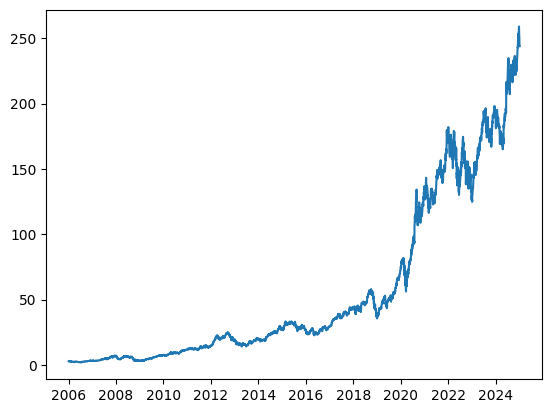

In [7]:
plt.plot(df.index, df.Close)
plt.show()

In [8]:
data = data[data.index.year >= 2015].reset_index()
data = data.set_index('Date')
df = data[['close']].rename(columns={'close': 'Close'})

print(f"Dataset: {df.shape[0]} trading days  |  {df.index.min().date()} → {df.index.max().date()}")
print(df.describe())

Dataset: 2518 trading days  |  2015-01-02 → 2025-01-03
             Close
count  2518.000000
mean     96.481120
std      65.361557
min      22.584999
25%      37.650624
50%      66.752502
75%     152.929996
max     259.019989


EDA: Closing price + 30-day rolling statistics

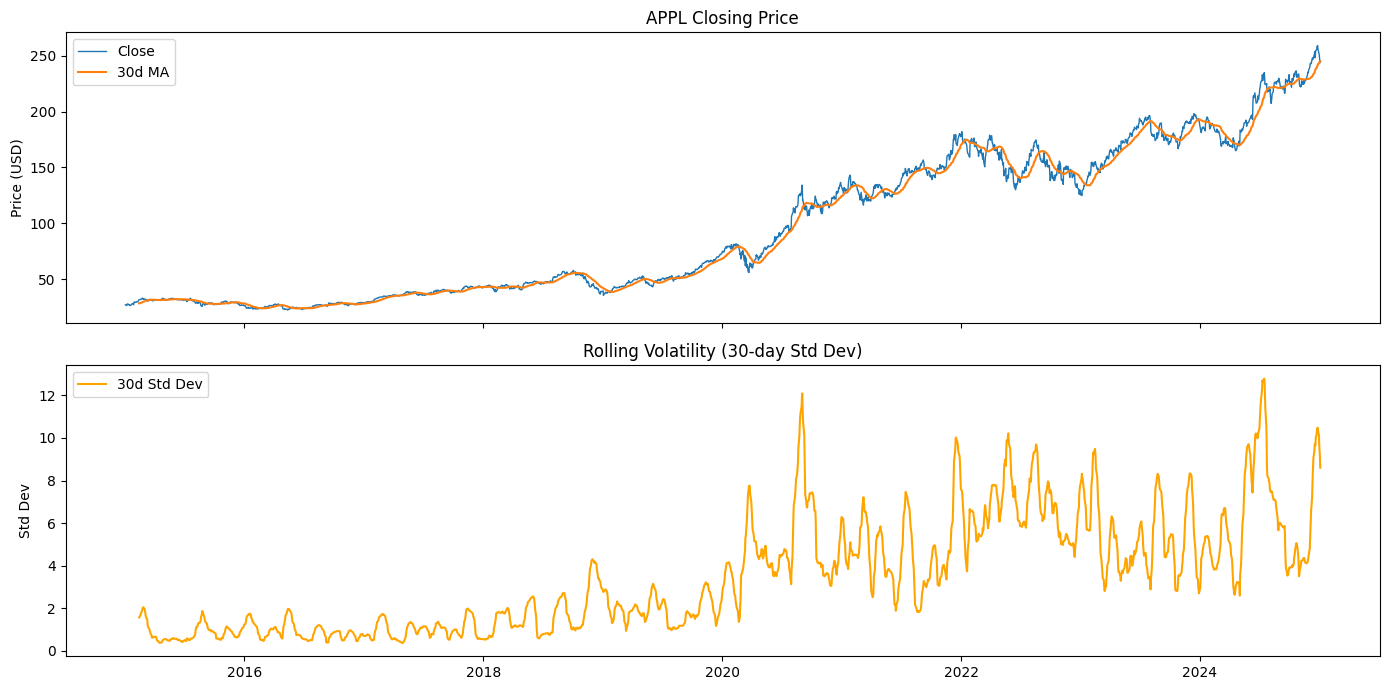

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
 
axes[0].plot(df["Close"], label="Close", linewidth=1)
axes[0].plot(df["Close"].rolling(30).mean(), label="30d MA", linewidth=1.5)
axes[0].set_title(f"APPL Closing Price")
axes[0].legend()
axes[0].set_ylabel("Price (USD)")
 
axes[1].plot(df["Close"].rolling(30).std(), color="orange", label="30d Std Dev")
axes[1].set_title("Rolling Volatility (30-day Std Dev)")
axes[1].legend()
axes[1].set_ylabel("Std Dev")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
plt.tight_layout()
plt.savefig("eda_price.png", dpi=150)
plt.show()

Daily returns distribution

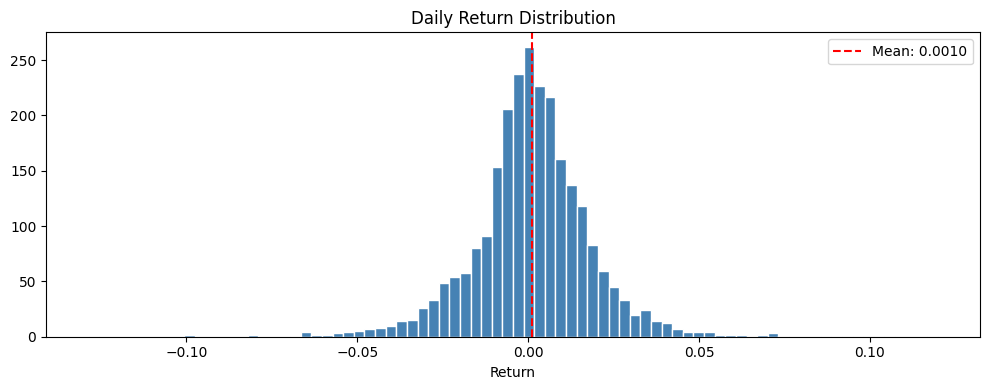

In [10]:
returns = df["Close"].pct_change().dropna()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(returns, bins=80, edgecolor="white", color="steelblue")
ax.axvline(returns.mean(), color="red", linestyle="--", label=f"Mean: {returns.mean():.4f}")
ax.set_title("Daily Return Distribution")
ax.set_xlabel("Return")
ax.legend()
plt.tight_layout()
plt.savefig("eda_returns.png", dpi=150)
plt.show()

## Section 3: Stationarity Testing (ADF)
The Augmented Dickey-Fuller test checks for a unit root.
H0: series has a unit root (non-stationary).
If p-value < 0.05, we reject H0 → series is stationary.

In [11]:
def adf_test(series, label="Series"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\nADF Test — {label}")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Lags Used      : {result[2]}")
    print(f"  Stationary     : {'YES' if result[1] < 0.05 else 'NO'}")
    return result[1] < 0.05
 
is_stationary = adf_test(df["Close"], label="Close Price")
 
# First-difference if non-stationary
df["Close_diff"] = df["Close"].diff()
adf_test(df["Close_diff"].dropna(), label="First-Differenced Close")


ADF Test — Close Price
  Test Statistic : 0.5635
  p-value        : 0.9867
  Lags Used      : 0
  Stationary     : NO

ADF Test — First-Differenced Close
  Test Statistic : -15.7944
  p-value        : 0.0000
  Lags Used      : 9
  Stationary     : YES


True

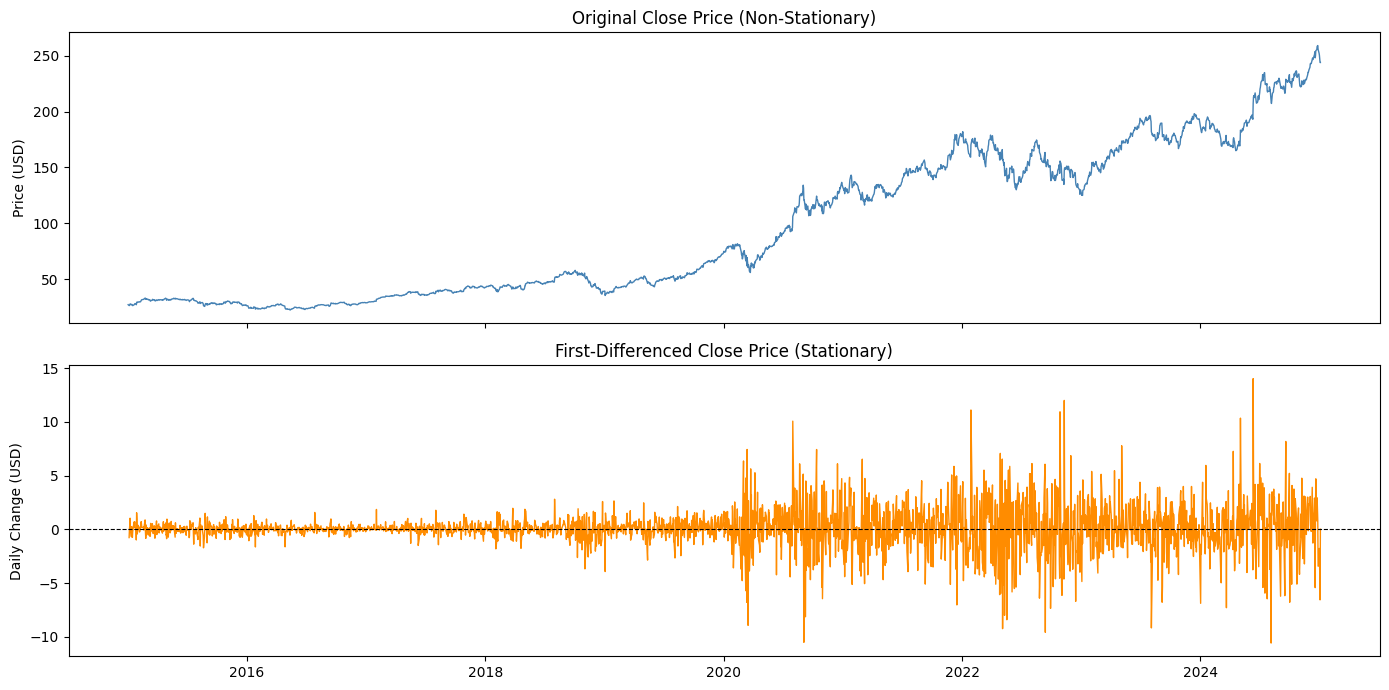

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df["Close"], linewidth=1, color="steelblue")
axes[0].set_title("Original Close Price (Non-Stationary)")
axes[0].set_ylabel("Price (USD)")

axes[1].plot(df["Close"].diff(), linewidth=1, color="darkorange")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("First-Differenced Close Price (Stationary)")
axes[1].set_ylabel("Daily Change (USD)")

plt.tight_layout()
plt.show()

## Section 4: ACF / PACF Plots
Used to determine ARIMA (p, d, q) parameters.
- PACF cuts off at lag p → AR order
- ACF cuts off at lag q → MA order

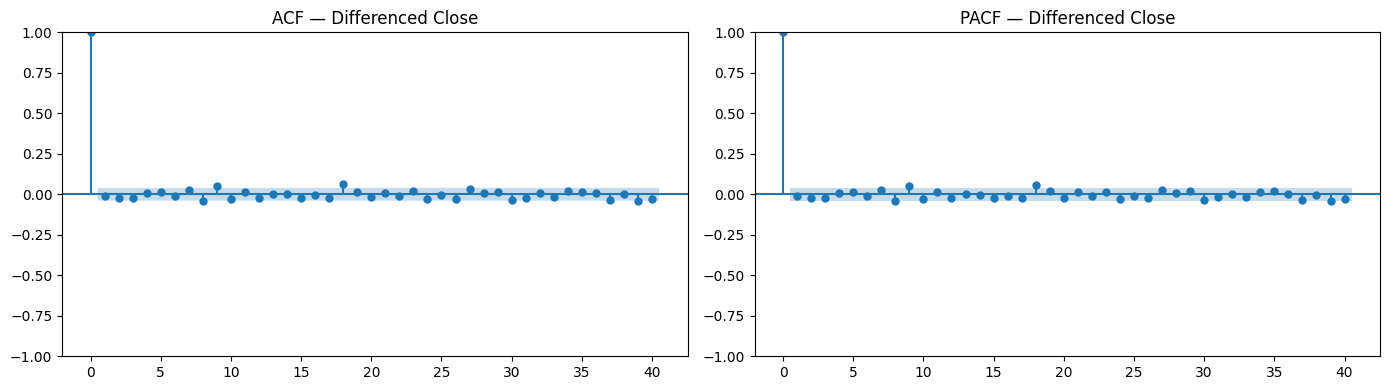

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Close_diff"].dropna(), lags=40, ax=axes[0], title="ACF — Differenced Close")
plot_pacf(df["Close_diff"].dropna(), lags=40, ax=axes[1], title="PACF — Differenced Close")
plt.tight_layout()
plt.savefig("acf_pacf.png", dpi=150)
plt.show()

## Section 5: Train/Test Split

Train: 2458 observations  |  Test: 60 observations


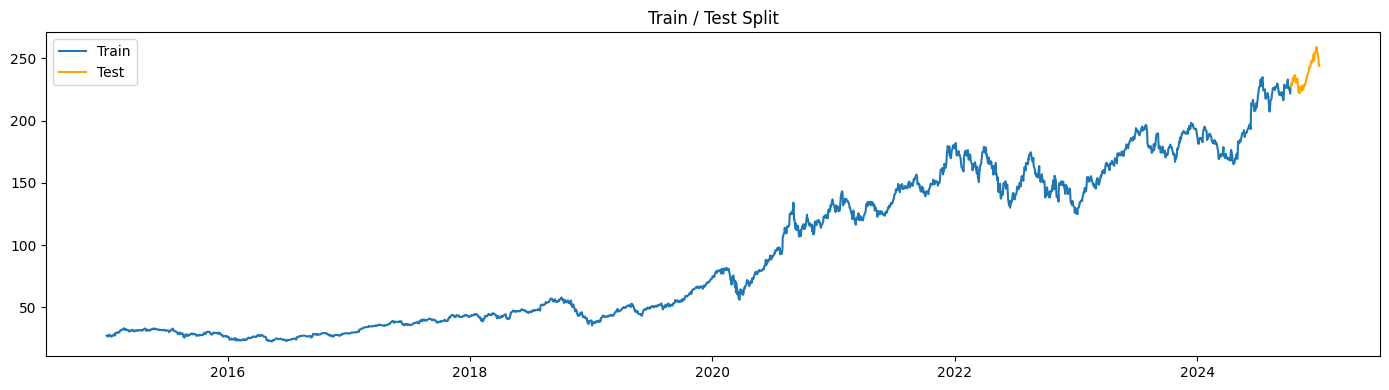

In [14]:
train = df["Close"].iloc[:-TEST_SIZE]
test  = df["Close"].iloc[-TEST_SIZE:]
 
print(f"Train: {len(train)} observations  |  Test: {len(test)} observations")
 
plt.figure(figsize=(14, 4))
plt.plot(train, label="Train")
plt.plot(test,  label="Test", color="orange")
plt.title("Train / Test Split")
plt.legend()
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=150)
plt.show()

## Section 6: SARIMAX Model
SARIMAX(p, d, q)(P, D, Q, s) — adds seasonal components on top of ARIMA.
A lightweight grid search is run over p, q, P, Q to minimise AIC.

In [15]:
def sarimax_grid_search(train_series, p_range=(0,3), q_range=(0,3), P_range=(0,2), Q_range=(0,2), d=1, D=1, s=5):
    """Simple AIC-based grid search for SARIMAX order."""
    best_aic = np.inf
    best_order = None
    best_seasonal = None
 
    combos = list(product(range(*p_range), range(*q_range), range(*P_range), range(*Q_range)))
    print(f"Testing {len(combos)} SARIMAX configurations…")
 
    for p, q, P, Q in combos:
        try:
            model = SARIMAX(train_series,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, s),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p, d, q)
                best_seasonal = (P, D, Q, s)
        except Exception:
            continue
 
    print(f"Best order: {best_order}  |  Seasonal: {best_seasonal}  |  AIC: {best_aic:.2f}")
    return best_order, best_seasonal

sarimax_order, sarimax_seasonal = sarimax_grid_search(train)

Testing 36 SARIMAX configurations…


/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but i

Best order: (0, 1, 2)  |  Seasonal: (0, 1, 1, 5)  |  AIC: 10234.60


/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fit final SARIMAX and generate test-set predictions

In [ ]:
sarimax_model = SARIMAX(train,
                        order=sarimax_order,
                        seasonal_order=sarimax_seasonal,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
 
print(sarimax_model.summary())

/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                               Close   No. Observations:                 2458
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 5)   Log Likelihood               -5113.299
Date:                             Mon, 04 May 2026   AIC                          10234.599
Time:                                     22:23:43   BIC                          10257.804
Sample:                                          0   HQIC                         10243.033
                                            - 2458                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0229      0.013     -1.802      0.072      -0.048       0.002
ma.L2         -0.0211      

/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## Section 7: XGBoost Regressor Model
Converts the time series into a supervised learning problem using lag features.
Lags of the target (Close price) are the input features; the next day's Close is the label.

In [17]:
def make_lag_features(series, n_lags=20):
    """Create a supervised dataset from lag features."""
    df_feat = pd.DataFrame({"Close": series})
    for lag in range(1, n_lags + 1):
        df_feat[f"lag_{lag}"] = df_feat["Close"].shift(lag)
    df_feat.dropna(inplace=True)
    X = df_feat.drop(columns="Close")
    y = df_feat["Close"]
    return X, y
 
N_LAGS = 20

# Scale the full series, then split
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[["Close"]])
scaled_series = pd.Series(scaled.flatten(), index=df.index)
 
X_all, y_all = make_lag_features(scaled_series, n_lags=N_LAGS)
X_all.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20
Date,,,,,,,,,,,,,,,,,,,,
2015-02-02,0.028359,0.030199,0.026403,0.019879,0.024066,0.023939,0.023326,0.020312,0.019435,0.016548,0.017426,0.020576,0.021021,0.019995,0.022913,0.022786,0.018409,0.016833,0.016823,0.020080
2015-02-03,0.029913,0.028359,0.030199,0.026403,0.019879,0.024066,0.023939,0.023326,0.020312,0.019435,0.016548,0.017426,0.020576,0.021021,0.019995,0.022913,0.022786,0.018409,0.016833,0.016823
2015-02-04,0.029934,0.029913,0.028359,0.030199,0.026403,0.019879,0.024066,0.023939,0.023326,0.020312,0.019435,0.016548,0.017426,0.020576,0.021021,0.019995,0.022913,0.022786,0.018409,0.016833
2015-02-05,0.030896,0.029934,0.029913,0.028359,0.030199,0.026403,0.019879,0.024066,0.023939,0.023326,0.020312,0.019435,0.016548,0.017426,0.020576,0.021021,0.019995,0.022913,0.022786,0.018409
2015-02-06,0.031298,0.030896,0.029934,0.029913,0.028359,0.030199,0.026403,0.019879,0.024066,0.023939,0.023326,0.020312,0.019435,0.016548,0.017426,0.020576,0.021021,0.019995,0.022913,0.022786


In [18]:
# Align with original train/test boundaries
split_idx = len(train) - N_LAGS   # offset for dropped NaN rows
X_train_xgb = X_all.iloc[:split_idx]
y_train_xgb = y_all.iloc[:split_idx]
X_test_xgb  = X_all.iloc[split_idx:]
y_test_xgb  = y_all.iloc[split_idx:]
 
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    early_stopping_rounds=20,
    eval_metric="rmse"
)

In [19]:
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)],
    verbose=False
)
 
xgb_pred_scaled = xgb_model.predict(X_test_xgb)
xgb_pred = scaler.inverse_transform(xgb_pred_scaled.reshape(-1, 1)).flatten()
xgb_pred_series = pd.Series(xgb_pred, index=y_test_xgb.index)

## Section 8: LSTM Model
LSTM (Long Short-Term Memory) is a recurrent neural network that learns sequential patterns.
Unlike XGBoost which uses flat lag features, LSTM receives a 3D input:
(samples, timesteps, features) — preserving the temporal order of the sequence.
It uses the same scaled data and N_LAGS window as XGBoost.

In [25]:
def make_sequences(series_values, n_lags):
    """Reshape scaled series into (samples, timesteps, 1) for LSTM input."""
    X, y = [], []
    for i in range(n_lags, len(series_values)):
        X.append(series_values[i - n_lags:i])
        y.append(series_values[i])
    return np.array(X), np.array(y)
 
# Build sequences from scaled series
scaled_values = scaled_series.values
X_seq, y_seq = make_sequences(scaled_values, N_LAGS)
 
# Reshape to (samples, timesteps, 1)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)
 
# Train/test split — same boundary as XGBoost
split_idx_lstm = len(train) - N_LAGS
X_train_lstm = X_seq[:split_idx_lstm]
y_train_lstm = y_seq[:split_idx_lstm]
X_test_lstm  = X_seq[split_idx_lstm:]
y_test_lstm  = y_seq[split_idx_lstm:]

In [26]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(N_LAGS, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
 
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 20, 64)            16896     
                                                                 
 dropout_2 (Dropout)         (None, 20, 64)            0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [27]:
# Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
 
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
69/69 [==============================] - 2s 9ms/step - loss: 0.0101 - val_loss: 0.0013
Epoch 2/100
69/69 [==============================] - 0s 5ms/step - loss: 0.0018 - val_loss: 8.7048e-04
Epoch 3/100
69/69 [==============================] - 0s 5ms/step - loss: 0.0017 - val_loss: 7.7359e-04
Epoch 4/100
69/69 [==============================] - 1s 7ms/step - loss: 0.0014 - val_loss: 7.8562e-04
Epoch 5/100
69/69 [==============================] - 0s 6ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/100
69/69 [==============================] - 0s 6ms/step - loss: 0.0013 - val_loss: 0.0035
Epoch 7/100
69/69 [==============================] - 0s 5ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 8/100
69/69 [==============================] - 0s 5ms/step - loss: 0.0014 - val_loss: 0.0029
Epoch 9/100
69/69 [==============================] - 0s 5ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 10/100
69/69 [==============================] - 0s 6ms/step - loss: 0.0012 - val_loss: 7.51

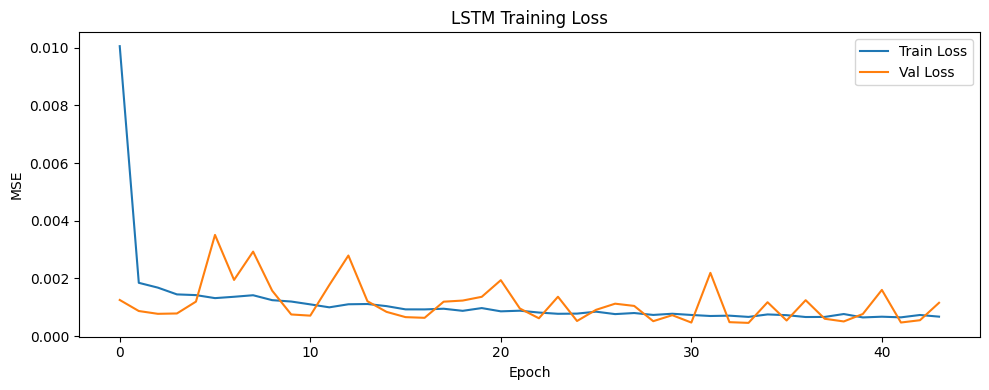

In [28]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Generate test set predictions
lstm_pred_scaled = lstm_model.predict(X_test_lstm)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_pred_series = pd.Series(lstm_pred, index=y_test_xgb.index)

2/2 [==============================] - 0s 3ms/step


## Section 9: Bootstrap Confidence Intervals (XGBoost & LSTM)
SARIMAX has built-in CI via get_forecast().
For XGBoost and LSTM, we use bootstrap: train N models on resampled data,
collect predictions, then take the 10th/90th percentile as the 80% CI band.

In [30]:
sarimax_result = sarimax_model.get_forecast(steps=TEST_SIZE)
sarimax_pred = sarimax_result.predicted_mean
sarimax_pred.index = test.index
sarimax_ci = sarimax_result.conf_int(alpha=0.2)  # 80% CI
sarimax_ci.index = test.index

/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [42]:
N_BOOTSTRAP = 50
print(f"Running {N_BOOTSTRAP} bootstrap iterations for XGBoost CI...")

xgb_boot_models = []
boot_preds_xgb = np.zeros((N_BOOTSTRAP, len(X_test_xgb)))
for i in range(N_BOOTSTRAP):
    idx = np.random.choice(len(X_train_xgb), len(X_train_xgb), replace=True)
    xgb_boot = XGBRegressor(n_estimators=300, learning_rate=0.05,
                             max_depth=5, random_state=i)
    xgb_boot.fit(X_train_xgb.iloc[idx], y_train_xgb.iloc[idx], verbose=False)
    boot_preds_xgb[i] = xgb_boot.predict(X_test_xgb)
    xgb_boot_models.append(xgb_boot)
 
xgb_lower = scaler.inverse_transform(
    np.percentile(boot_preds_xgb, 10, axis=0).reshape(-1, 1)).flatten()
xgb_upper = scaler.inverse_transform(
    np.percentile(boot_preds_xgb, 90, axis=0).reshape(-1, 1)).flatten()
print("Bootstrap complete.")

Running 50 bootstrap iterations for XGBoost CI...
Bootstrap complete.


In [43]:
print(f"Running {N_BOOTSTRAP} bootstrap iterations for LSTM CI...")
 
lstm_boot_models = []
boot_preds_lstm = np.zeros((N_BOOTSTRAP, len(X_test_lstm)))
for i in range(N_BOOTSTRAP):
    idx = np.random.choice(len(X_train_lstm), len(X_train_lstm), replace=True)
    lstm_boot = Sequential([
        LSTM(64, return_sequences=True, input_shape=(N_LAGS, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    lstm_boot.compile(optimizer='adam', loss='mse')
    lstm_boot.fit(X_train_lstm[idx], y_train_lstm[idx],
                  epochs=10, batch_size=32, verbose=0)
    boot_preds_lstm[i] = lstm_boot.predict(X_test_lstm, verbose=0).flatten()
    lstm_boot_models.append(lstm_boot)
 
lstm_lower = scaler.inverse_transform(
    np.percentile(boot_preds_lstm, 10, axis=0).reshape(-1, 1)).flatten()
lstm_upper = scaler.inverse_transform(
    np.percentile(boot_preds_lstm, 90, axis=0).reshape(-1, 1)).flatten()
 
print("Bootstrap complete.")

Running 50 bootstrap iterations for LSTM CI...
Bootstrap complete.


## Section 10: Evaluation Metrics
Metrics computed on the hold-out test set for both models.
- R²   : proportion of variance explained (1.0 = perfect)
- RMSE : root mean squared error (same unit as price)
- MAPE : mean absolute percentage error

In [36]:
def evaluate(actual, predicted, label="Model"):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual.values - predicted.values) / actual.values)) * 100
    print(f"\n{label}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return {"R2": r2, "RMSE": rmse, "MAPE": mape}
 
sarimax_metrics = evaluate(test, sarimax_pred, "SARIMAX")
 
# Align XGBoost predictions with test index (last TEST_SIZE rows)
xgb_test_actual = test.iloc[-len(xgb_pred_series):]
xgb_metrics = evaluate(xgb_test_actual, xgb_pred_series, "XGBoost")

lstm_test_actual = test.iloc[-len(lstm_pred_series):]
lstm_metrics = evaluate(lstm_test_actual, lstm_pred_series, "LSTM")


SARIMAX
  R²   : -0.5179
  RMSE : 12.8649
  MAPE : 4.03%

XGBoost
  R²   : -2.0801
  RMSE : 18.3257
  MAPE : 6.07%

LSTM
  R²   : 0.6647
  RMSE : 6.0459
  MAPE : 2.24%


## Section 11: Visualise Predictions vs Actuals

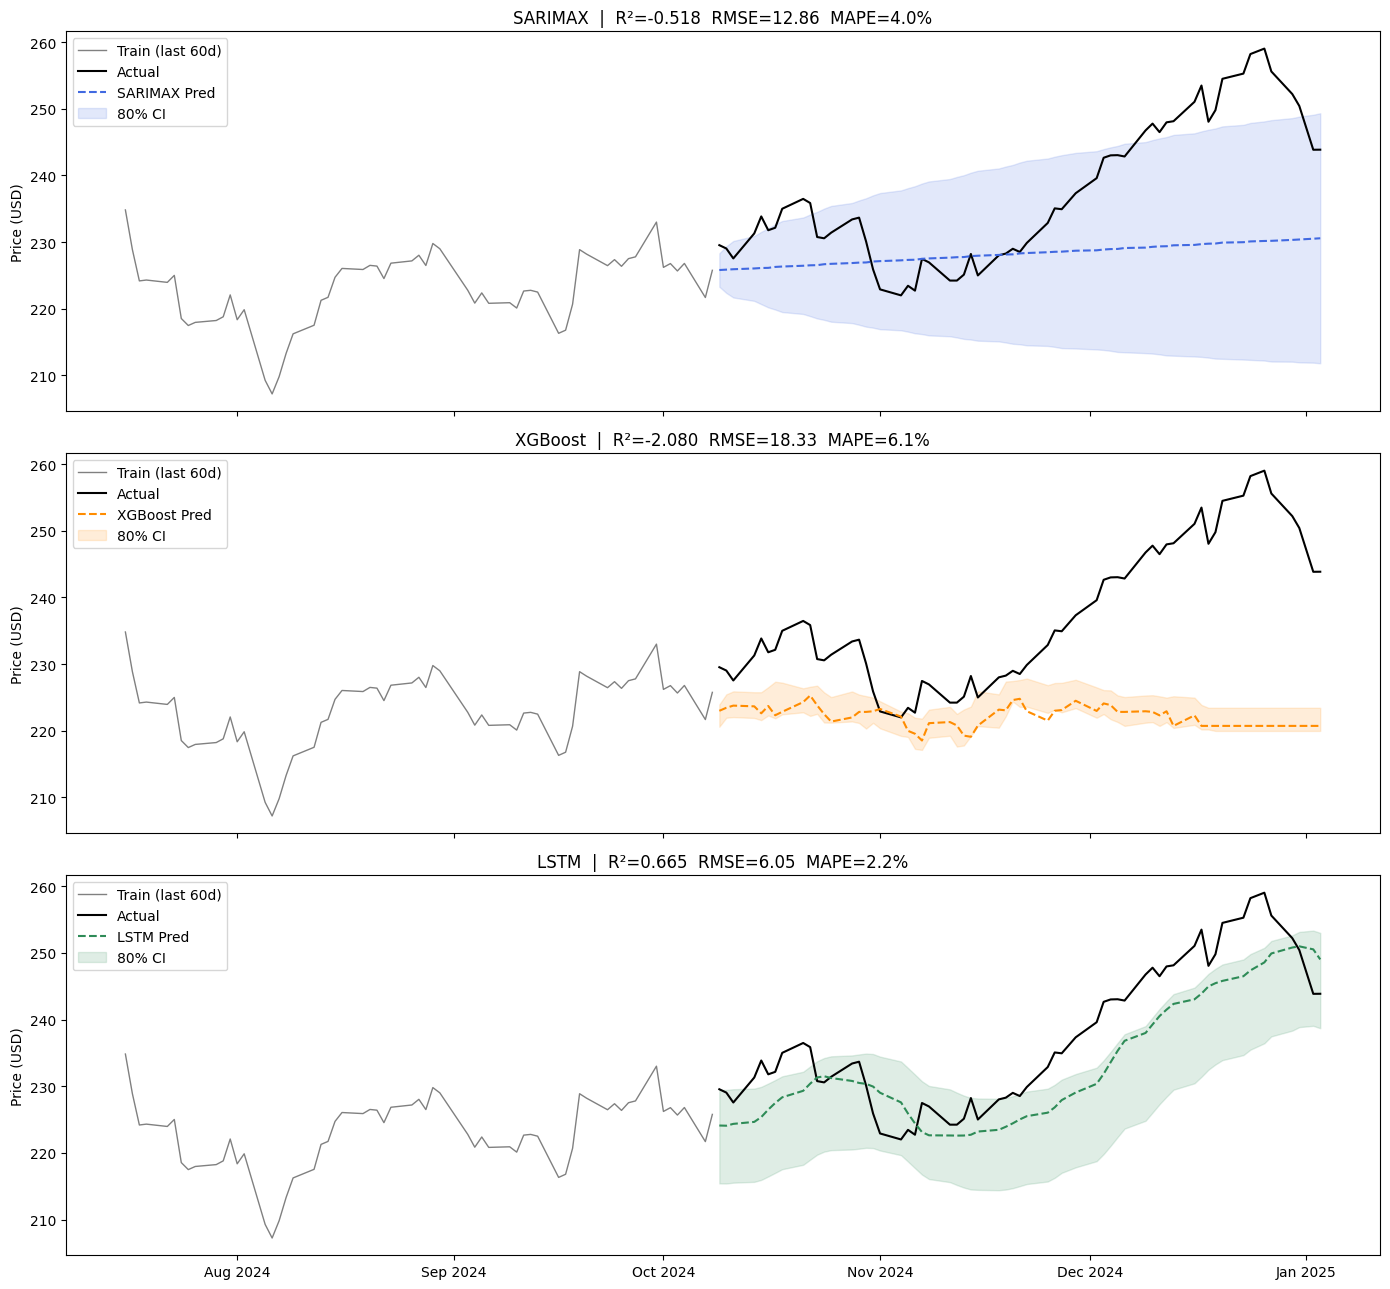

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
 
xgb_ci_index = y_test_xgb.index
lstm_ci_index = y_test_xgb.index
 
for ax, preds, metrics, label, color in zip(
    axes,
    [sarimax_pred, xgb_pred_series, lstm_pred_series],
    [sarimax_metrics, xgb_metrics, lstm_metrics],
    ["SARIMAX", "XGBoost", "LSTM"],
    ["royalblue", "darkorange", "seagreen"]
):
    ax.plot(train.iloc[-60:], label="Train (last 60d)", color="gray", linewidth=1)
    ax.plot(test, label="Actual", color="black", linewidth=1.5)
    ax.plot(preds, label=f"{label} Pred", color=color, linestyle="--", linewidth=1.5)
 
    if label == "SARIMAX":
        ax.fill_between(test.index,
                        sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1],
                        color=color, alpha=0.15, label="80% CI")
    elif label == "XGBoost":
        ax.fill_between(xgb_ci_index, xgb_lower, xgb_upper,
                        color=color, alpha=0.15, label="80% CI")
    elif label == "LSTM":
        ax.fill_between(lstm_ci_index, lstm_lower, lstm_upper,
                        color=color, alpha=0.15, label="80% CI")
 
    ax.set_title(
        f"{label}  |  R²={metrics['R2']:.3f}  RMSE={metrics['RMSE']:.2f}  MAPE={metrics['MAPE']:.1f}%"
    )
    ax.legend()
    ax.set_ylabel("Price (USD)")
 
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig("predictions_vs_actual.png", dpi=150)
plt.show()

## Section 12: 5-Day Future Forecast
Both models extend predictions FORECAST_HORIZON days beyond the last known date.

In [45]:
# --- SARIMAX future forecast ---
sarimax_full = SARIMAX(df["Close"],
                       order=sarimax_order,
                       seasonal_order=sarimax_seasonal,
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)

future_dates = pd.bdate_range(start=df.index[-1] + pd.Timedelta(days=1),
                               periods=FORECAST_HORIZON)

sarimax_future_result = sarimax_full.get_forecast(steps=FORECAST_HORIZON)
sarimax_future = sarimax_future_result.predicted_mean
sarimax_future.index = future_dates
sarimax_future_ci = sarimax_future_result.conf_int(alpha=0.2)
sarimax_future_ci.index = future_dates

/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/time_series_analysis/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [46]:
# --- XGBoost future forecast (recursive) + CI from saved boot models ---
last_window = scaled_series.iloc[-N_LAGS:].values.tolist()
xgb_future_scaled = []
for _ in range(FORECAST_HORIZON):
    x_input = np.array(last_window[-N_LAGS:][::-1]).reshape(1, -1)
    next_val = np.clip(float(xgb_model.predict(x_input)[0]), 0, 1)
    xgb_future_scaled.append(next_val)
    last_window.append(next_val)

xgb_future = scaler.inverse_transform(
    np.array(xgb_future_scaled).reshape(-1, 1)).flatten()
xgb_future_series = pd.Series(xgb_future, index=future_dates)

boot_future_xgb = np.zeros((N_BOOTSTRAP, FORECAST_HORIZON))
for i, xgb_boot in enumerate(xgb_boot_models):
    win = scaled_series.iloc[-N_LAGS:].values.tolist()
    for j in range(FORECAST_HORIZON):
        x_in = np.array(win[-N_LAGS:][::-1]).reshape(1, -1)
        nv = np.clip(float(xgb_boot.predict(x_in)[0]), 0, 1)
        boot_future_xgb[i, j] = nv
        win.append(nv)

xgb_lower_future = scaler.inverse_transform(
    np.percentile(boot_future_xgb, 10, axis=0).reshape(-1, 1)).flatten()
xgb_upper_future = scaler.inverse_transform(
    np.percentile(boot_future_xgb, 90, axis=0).reshape(-1, 1)).flatten()

In [47]:
# --- LSTM future forecast (recursive) + CI from saved boot models ---
last_window_lstm = scaled_series.iloc[-N_LAGS:].values.tolist()
lstm_future_scaled = []
for _ in range(FORECAST_HORIZON):
    x_input = np.array(last_window_lstm[-N_LAGS:]).reshape(1, N_LAGS, 1)
    next_val = np.clip(float(lstm_model.predict(x_input, verbose=0)[0][0]), 0, 1)
    lstm_future_scaled.append(next_val)
    last_window_lstm.append(next_val)

lstm_future = scaler.inverse_transform(
    np.array(lstm_future_scaled).reshape(-1, 1)).flatten()
lstm_future_series = pd.Series(lstm_future, index=future_dates)

boot_future_lstm = np.zeros((N_BOOTSTRAP, FORECAST_HORIZON))
for i, lstm_boot in enumerate(lstm_boot_models):
    win = scaled_series.iloc[-N_LAGS:].values.tolist()
    for j in range(FORECAST_HORIZON):
        x_in = np.array(win[-N_LAGS:]).reshape(1, N_LAGS, 1)
        nv = np.clip(float(lstm_boot.predict(x_in, verbose=0)[0][0]), 0, 1)
        boot_future_lstm[i, j] = nv
        win.append(nv)

lstm_lower_future = scaler.inverse_transform(
    np.percentile(boot_future_lstm, 10, axis=0).reshape(-1, 1)).flatten()
lstm_upper_future = scaler.inverse_transform(
    np.percentile(boot_future_lstm, 90, axis=0).reshape(-1, 1)).flatten()

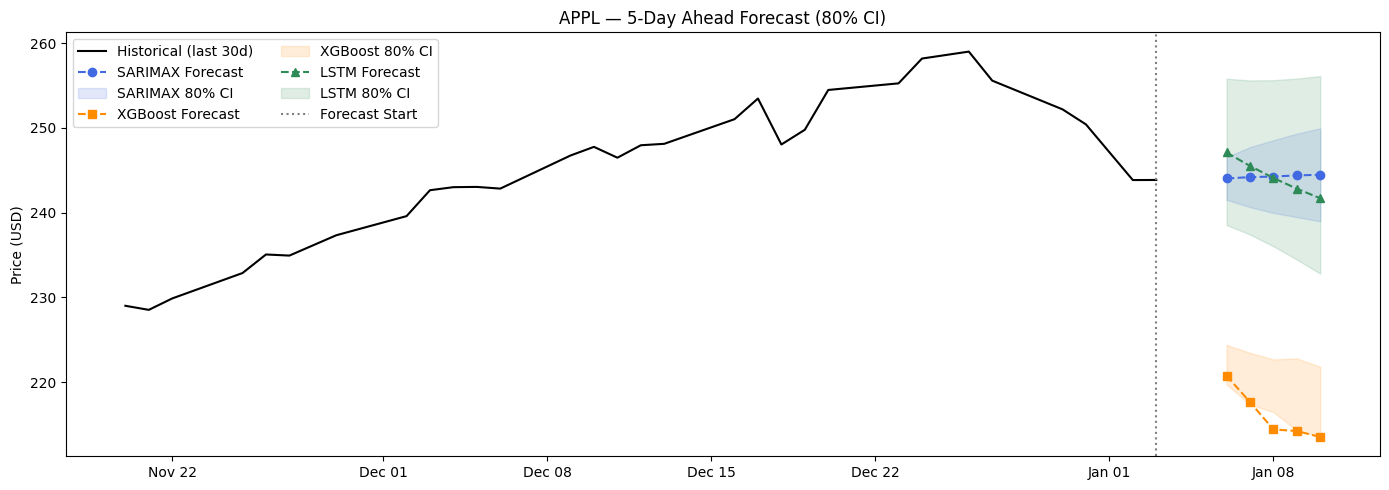

In [48]:
# Plot 5-day forecast with CI for all three models
fig, ax = plt.subplots(figsize=(14, 5))
history_window = df["Close"].iloc[-30:]

ax.plot(history_window, label="Historical (last 30d)", color="black", linewidth=1.5)

ax.plot(sarimax_future, marker="o", label="SARIMAX Forecast",
        color="royalblue", linestyle="--", linewidth=1.5)
ax.fill_between(future_dates,
                sarimax_future_ci.iloc[:, 0], sarimax_future_ci.iloc[:, 1],
                color="royalblue", alpha=0.15, label="SARIMAX 80% CI")

ax.plot(xgb_future_series, marker="s", label="XGBoost Forecast",
        color="darkorange", linestyle="--", linewidth=1.5)
ax.fill_between(future_dates, xgb_lower_future, xgb_upper_future,
                color="darkorange", alpha=0.15, label="XGBoost 80% CI")

ax.plot(lstm_future_series, marker="^", label="LSTM Forecast",
        color="seagreen", linestyle="--", linewidth=1.5)
ax.fill_between(future_dates, lstm_lower_future, lstm_upper_future,
                color="seagreen", alpha=0.15, label="LSTM 80% CI")

ax.axvline(df.index[-1], color="gray", linestyle=":", label="Forecast Start")
ax.set_title(f"{TICKER} — {FORECAST_HORIZON}-Day Ahead Forecast (80% CI)")
ax.set_ylabel("Price (USD)")
ax.legend(ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.savefig("future_forecast.png", dpi=150)
plt.show()

In [49]:
# Tabular output
print("\n5-Day Forecast:")
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "SARIMAX": sarimax_future.values.round(2),
    "XGBoost": xgb_future.round(2),
    "LSTM": lstm_future.round(2)
})
print(forecast_df.to_string(index=False))


5-Day Forecast:
      Date  SARIMAX  XGBoost   LSTM
2025-01-06   244.04   220.74 247.11
2025-01-07   244.20   217.63 245.51
2025-01-08   244.26   214.40 244.10
2025-01-09   244.40   214.21 242.83
2025-01-10   244.47   213.50 241.70
